In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy.stats import norm
import seaborn as sns

In [2]:
def get_values_from_log(my_file, testing=None):
    with open(my_file, "r") as f:
        log_file = f.readlines()

    episodes = []
    reward = []
    length = []
    collisions = []
    goal = []
    not_completed = []

    for i in range(1, len(log_file)):
        line = log_file[i].splitlines()
        line = line[0].split()
        episodes.append(line[0])
        reward.append(float(line[3]))
        collisions.append(int(float(line[4])))
        goal.append(int(float(line[5])))
        not_completed.append(int(float(line[6])))
        length.append(float(line[7]))
            
    return episodes, reward, collisions, goal, not_completed, length

In [3]:
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

In [4]:
my_files = [
    {
        "file": "file_4_agents_1",
        "file_name": "../last_test/checkpoints_obstacle_test_1/agent_1/2026-07-13T08-04-11/log",
        "experiment" : 4
    },
    {
        "file": "file_4_agents_2",
        "file_name": "../last_test/checkpoints_obstacle_test_1/agent_2/2026-07-13T08-04-11/log",
        "experiment" : 4
    },
    {
        "file": "file_4_agents_3",
        "file_name": "../last_test/checkpoints_obstacle_test_1/agent_3/2026-07-13T08-04-11/log",
        "experiment" : 4
    },
    {
        "file": "file_4_agents_4",
        "file_name": "../last_test/checkpoints_obstacle_test_1/agent_4/2026-07-13T08-04-11/log",
        "experiment" : 4
    },
]

df = pd.DataFrame()
for file in my_files:
    episodes, reward, collisions, goal, not_completed, length = get_values_from_log(file["file_name"])
    my_df = pd.DataFrame(zip(episodes, reward, length, collisions, goal), columns=["episode", "reward", "length", "collisions", "goal"])
    my_df["file"] = file["file"]
    my_df["experiment"] = file["experiment"]
    df = pd.concat([df, my_df], ignore_index=True)

column = "reward"
df["reward_normal"] = (df[column] - df[column].min()) / (df[column].max() - df[column].min())

In [5]:
display(df)

,episode,reward,length,collisions,goal,file,experiment,reward_normal
0,0,-10.368,11.0,1,0,file_4_agents_1,4,0.696741
1,1,-10.400,13.0,1,0,file_4_agents_1,4,0.695529
2,2,-10.368,11.0,1,0,file_4_agents_1,4,0.696741
3,3,-10.115,10.0,1,0,file_4_agents_1,4,0.706328
4,4,-10.368,11.0,1,0,file_4_agents_1,4,0.696741
...,...,...,...,...,...,...,...,...
795,195,-9.798,18.0,1,0,file_4_agents_4,4,0.718340
796,196,-9.836,18.0,1,0,file_4_agents_4,4,0.716900
797,197,-9.808,16.0,1,0,file_4_agents_4,4,0.717961
798,198,-9.852,18.0,1,0,file_4_agents_4,4,0.716294


In [6]:
# AGENTE 1, 2 y 3 ENTRENANDO

file_1 = "file_4_agents_1"
frame_1 = df[df["file"] == file_1]

file_2 = "file_4_agents_2"
frame_2 = df[df["file"] == file_2]

file_3 = "file_4_agents_3"
frame_3 = df[df["file"] == file_3]

file_4 = "file_4_agents_4"
frame_4 = df[df["file"] == file_4]

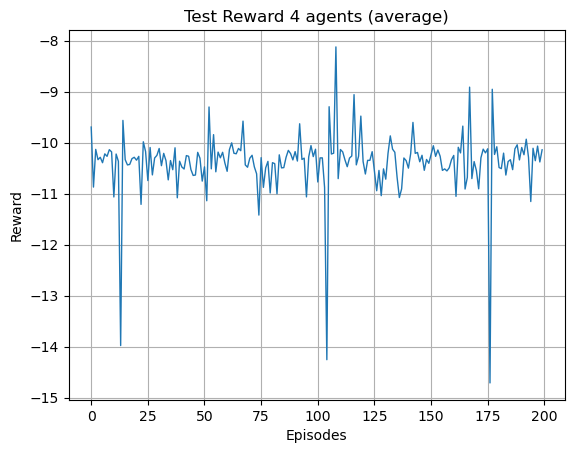

In [7]:
# AGENTE 1, 2 y 3 ENTRENANDO

rewards_df = pd.DataFrame({
    "agent_1": np.array(frame_1["reward"]),
    "agent_2": np.array(frame_2["reward"]),
    "agent_3": np.array(frame_3["reward"]),
    "agent_4": np.array(frame_4["reward"])
})

rewards_df["average"] = rewards_df[["agent_1", "agent_2", "agent_3", "agent_4"]].mean(axis=1)


fig, ax = plt.subplots()
ax.plot(np.arange(0, len(rewards_df["average"])), rewards_df["average"], linewidth=1, label='Agent 1')
ax.set(xlabel='Episodes', ylabel='Reward', title="Test Reward 4 agents (average)")
ax.grid()
plt.show()
# fig.savefig('moving_average_reward_experiment_4_test.png')

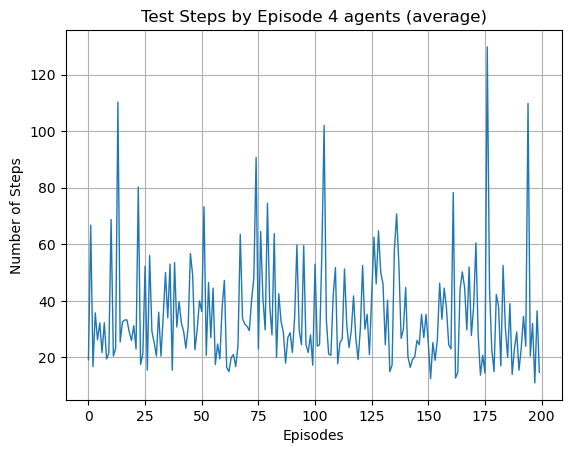

In [8]:
# AGENTE 1, 2 y 3 ENTRENANDO

steps_df = pd.DataFrame({
    "agent_1": np.array(frame_1["length"]),
    "agent_2": np.array(frame_2["length"]),
    "agent_3": np.array(frame_3["length"]),
    "agent_4": np.array(frame_4["length"])
})

steps_df["average"] = steps_df[["agent_1", "agent_2", "agent_3", "agent_4"]].mean(axis=1)


fig, ax = plt.subplots()
ax.plot(np.arange(0, len(steps_df["average"])), steps_df["average"], linewidth=1, label='Agent 1')
ax.set(xlabel='Episodes', ylabel='Number of Steps', title="Test Steps by Episode 4 agents (average)")
ax.grid()
plt.show()
# fig.savefig('moving_average_reward_experiment_4_test.png')

In [9]:
# AGENTE 1, 2 y 3 ENTRENANDO

agent_1_df = pd.DataFrame({
    "collisions": np.array(frame_1["collisions"]),
    "goal": np.array(frame_1["goal"])
})

agent_1_df["collision_sum"] = agent_1_df["collisions"].cumsum()
agent_1_df["goals_sum"] = agent_1_df["goal"].cumsum()

agent_2_df = pd.DataFrame({
    "collisions": np.array(frame_2["collisions"]),
    "goal": np.array(frame_2["goal"])
})

agent_2_df["collision_sum"] = agent_2_df["collisions"].cumsum()
agent_2_df["goals_sum"] = agent_2_df["goal"].cumsum()

agent_3_df = pd.DataFrame({
    "collisions": np.array(frame_3["collisions"]),
    "goal": np.array(frame_3["goal"])
})

agent_3_df["collision_sum"] = agent_3_df["collisions"].cumsum()
agent_3_df["goals_sum"] = agent_3_df["goal"].cumsum()

agent_4_df = pd.DataFrame({
    "collisions": np.array(frame_4["collisions"]),
    "goal": np.array(frame_4["goal"])
})

agent_4_df["collision_sum"] = agent_4_df["collisions"].cumsum()
agent_4_df["goals_sum"] = agent_4_df["goal"].cumsum()

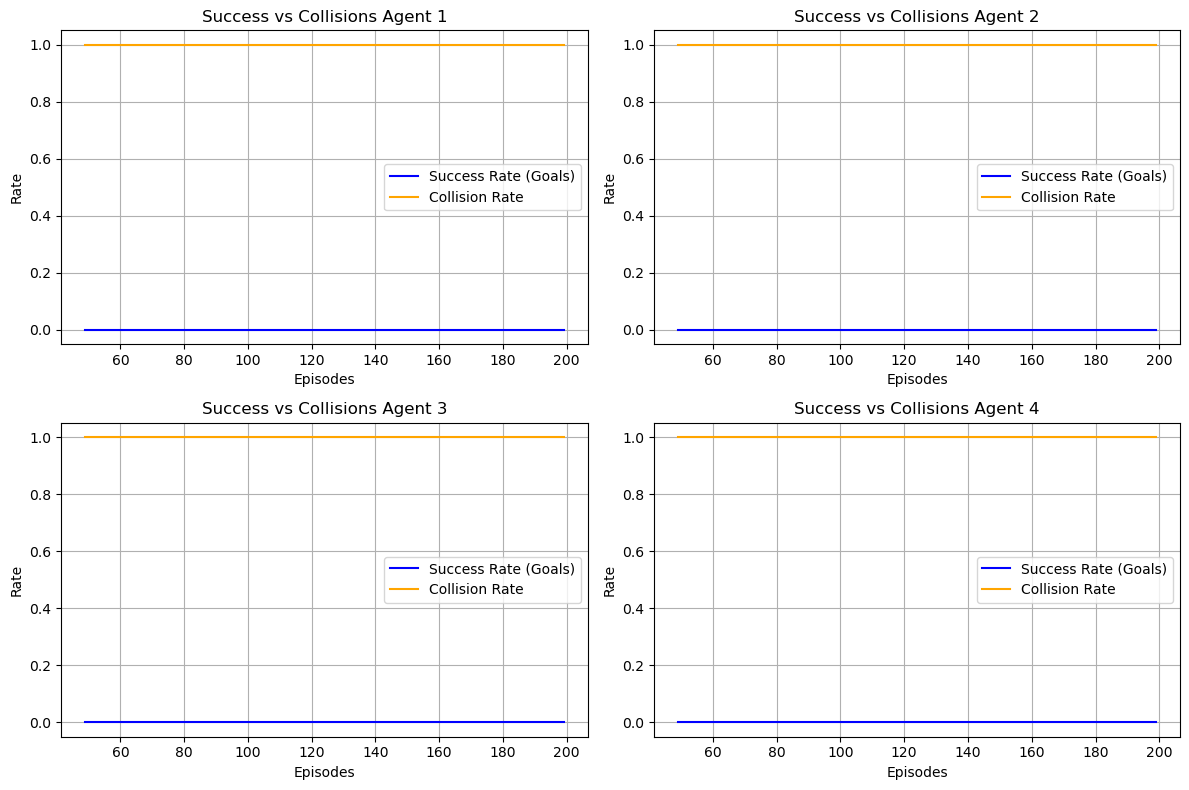

In [10]:
window = 50  # smoothing window

def success_rate(df):
    goals_rate = df["goal"].rolling(window).mean()
    collisions_rate = df["collisions"].rolling(window).mean()
    return goals_rate, collisions_rate

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for i, agent_df in enumerate([agent_1_df, agent_2_df, agent_3_df, agent_4_df]):
    goals_rate, collisions_rate = success_rate(agent_df)
    ax = axs[i//2, i%2]
    ax.plot(goals_rate, label="Success Rate (Goals)", color="blue")
    ax.plot(collisions_rate, label="Collision Rate", color="orange")
    ax.set(xlabel="Episodes", ylabel="Rate", title=f"Success vs Collisions Agent {i+1}")
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()
fig.savefig('success_vs_collisions_unsort.png')

In [11]:
# 